In [7]:
!pip install tensorflow

In [8]:
!pip install tensorflow-gpu

  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [58 lines of output]
      Traceback (most recent call last):
        File "C:\Users\markn\AppData\Local\Temp\pip-build-env-duaziaa6\overlay\Lib\site-packages\setuptools\_vendor\packaging\requirements.py", line 36, in __init__
          parsed = _parse_requirement(requirement_string)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\markn\AppData\Local\Temp\pip-build-env-duaziaa6\overlay\Lib\site-packages\setuptools\_vendor\packaging\_parser.py", line 71, in parse_requirement
          return _parse_requirement(Tokenizer(source, rules=DEFAULT_RULES))
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\markn\AppData\Local\Temp\pip-build-env-duaziaa6\overlay\Lib\site-packages\setuptools\_vendor\packaging\_parser.py", line 89, in _parse_requirement
          url, specifier, marker = _

In [9]:
import tensorflow as tf

In [10]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [11]:
print(tf.__version__)

2.21.0


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data Preprocessing

In [13]:
# import the libraries

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence

#Load the dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=20000)

In [14]:
x_train

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 82

In [15]:
# apply padding
x_train = sequence.pad_sequences(x_train, maxlen=100)
x_test = sequence.pad_sequences(x_test, maxlen=100)

In [16]:
x_train.shape, x_test.shape

((25000, 100), (25000, 100))

# Building the Model

In [17]:
# define an object (initilizing RNN)
model = tf.keras.models.Sequential()


In [18]:
# embedding layer
model.add(tf.keras.layers.Embedding(input_dim=20000, output_dim=128))

In [19]:
# LSTM Layer
model.add(tf.keras.layers.LSTM(units=128, activation='tanh', return_sequences=True))

In [20]:
# Output Layer
model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training the model

In [23]:
# rebuild the model with the correct input shape and then train
model = tf.keras.models.Sequential([
  tf.keras.layers.Embedding(input_dim=20000, output_dim=128, input_length=100),
  tf.keras.layers.LSTM(units=128),  # use return_sequences=True only if stacking another RNN afterwards
  tf.keras.layers.Dense(units=1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, batch_size=128, validation_data=(x_test, y_test))

Epoch 1/5


c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


196/196 ━━━━━━━━━━━━━━━━━━━━ 39s 192ms/step - accuracy: 0.7880 - loss: 0.4341 - val_accuracy: 0.8418 - val_loss: 0.3632
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 37s 187ms/step - accuracy: 0.9070 - loss: 0.2372 - val_accuracy: 0.8439 - val_loss: 0.3799
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 202ms/step - accuracy: 0.9422 - loss: 0.1574 - val_accuracy: 0.8256 - val_loss: 0.4466
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 55s 282ms/step - accuracy: 0.9600 - loss: 0.1108 - val_accuracy: 0.8308 - val_loss: 0.4738
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 55s 279ms/step - accuracy: 0.9745 - loss: 0.0725 - val_accuracy: 0.8198 - val_loss: 0.6862


In [24]:
# predictions
y_pred = (model.predict(x_test) > 0.5).astype("int32").ravel() 

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step


In [25]:
print(y_pred[15]), print(y_test[15])

0
0


(None, None)

In [26]:
# confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[11210  1290]
 [ 3214  9286]]


In [27]:
from sklearn.metrics import accuracy_score

acc_cm = accuracy_score(y_test, y_pred)
print(f"Accuracy from Confusion Matrix: {acc_cm}")

Accuracy from Confusion Matrix: 0.81984


# Learning Curve

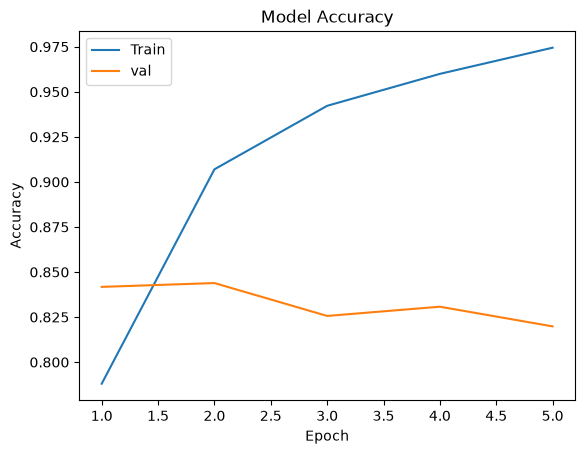

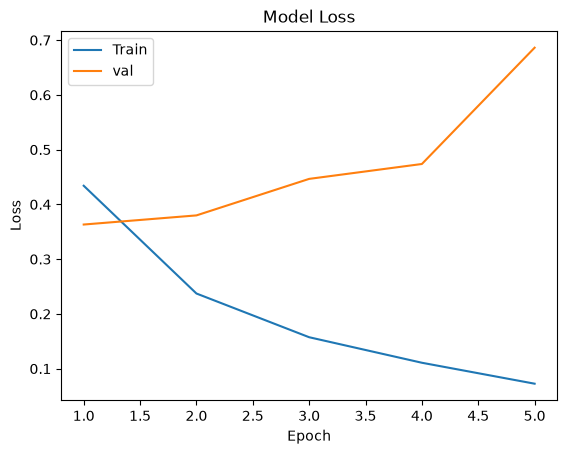

In [28]:
def learning_curve(history, epoch):
  epoch_range = range(1, epoch+1)
  plt.plot(epoch_range, history.history['accuracy'], label='Training Accuracy')
  plt.plot(epoch_range, history.history['val_accuracy'], label='Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Model Accuracy')
  plt.legend(['Train', 'val'], loc='upper left')
  plt.show()
  plt.plot(epoch_range, history.history['loss'], label='Training Loss')
  plt.plot(epoch_range, history.history['val_loss'], label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Model Loss')
  plt.legend(['Train', 'val'], loc='upper left')
  plt.show()

# Call the function with the history object from the training cell
# Make sure to run the training cell (index 19) first before running this cell
if 'history' in globals():
    learning_curve(history, 5)
else:
    print("Error: 'history' variable not found. Please run the training cell first.")
